In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.ma as ma

import base
import matrix
import tsp

In [14]:
xPos = np.loadtxt('point_x.txt')
yPos = np.loadtxt('point_y.txt')

distances = np.zeros((32, 32))
for k in range(32):
    for l in range(32):
        distances[k, l] = np.sqrt((xPos[k]-xPos[l])**2+(yPos[k]-yPos[l])**2)

points = np.linspace(0, 31, 32)

xPosBig = xPos*1000
yPosBig = yPos*1000

distancesBig = np.zeros((32, 32))
for k in range(32):
    for l in range(32):
        distancesBig[k, l] = np.sqrt((xPosBig[k]-xPosBig[l])**2+(yPosBig[k]-yPosBig[l])**2)

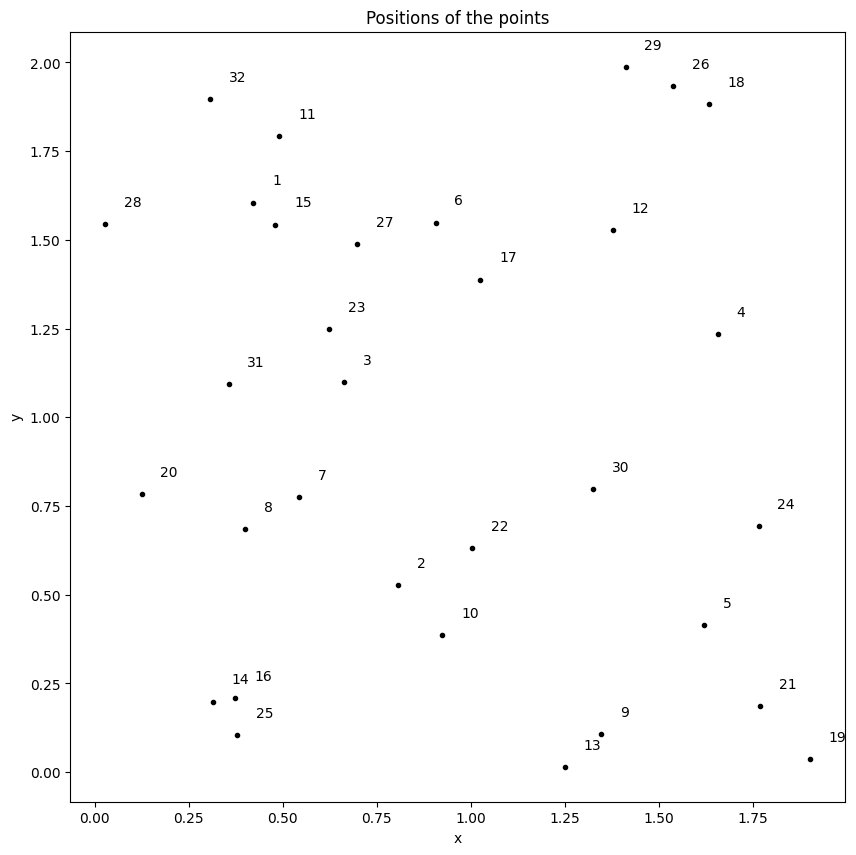

In [3]:
z = []
for i in range(len(xPos)):
    z.append(str(i+1))
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot()

plt.scatter(xPos, yPos, marker = '.', color = 'black')
plt.ylabel("y")
plt.xlabel("x")
plt.title("Positions of the points")

for i, txt in enumerate(z):
    ax.text(xPos[i]+0.05, yPos[i]+0.05, txt)

plt.show()

In [4]:
pathNN = tsp.nearestNeighbourJulius(points, 1, distances)

xPos_NN_order = np.zeros(len(points)+1)
yPos_NN_order = np.zeros(len(points)+1)

for i in range(len(points)+1):
    xPos_NN_order[i] = xPos[int(pathNN[i])-1]
    yPos_NN_order[i] = yPos[int(pathNN[i])-1]


pathDSNN = tsp.doubleSidedNearestNeighbourJulius(points, 1, distances)


xPos_DSNN_order = np.zeros(len(points)+1)
yPos_DSNN_order = np.zeros(len(points)+1)

for i in range(len(points)+1):
    xPos_DSNN_order[i] = xPos[int(pathDSNN[i])-1]
    yPos_DSNN_order[i] = yPos[int(pathDSNN[i])-1]

bestPathNN, minWeightNN, pathsNN, weightsNN = tsp.nearestNeighborAllJulius(points, distances)
bestPathDSNN, minWeightDSNN, pathsDSNN, weightsDSNN = tsp.doubleSidedNearestNeighborAllJulius(points, distances)

pathNearestInsertion = tsp.nearest_Insertion(distances)
weightNearestInsertion = base.totalTravelDist(pathNearestInsertion, distances)

pathsChristofides, weightsChristofides = tsp.christofidesAllJulius(distances, points.astype(int))

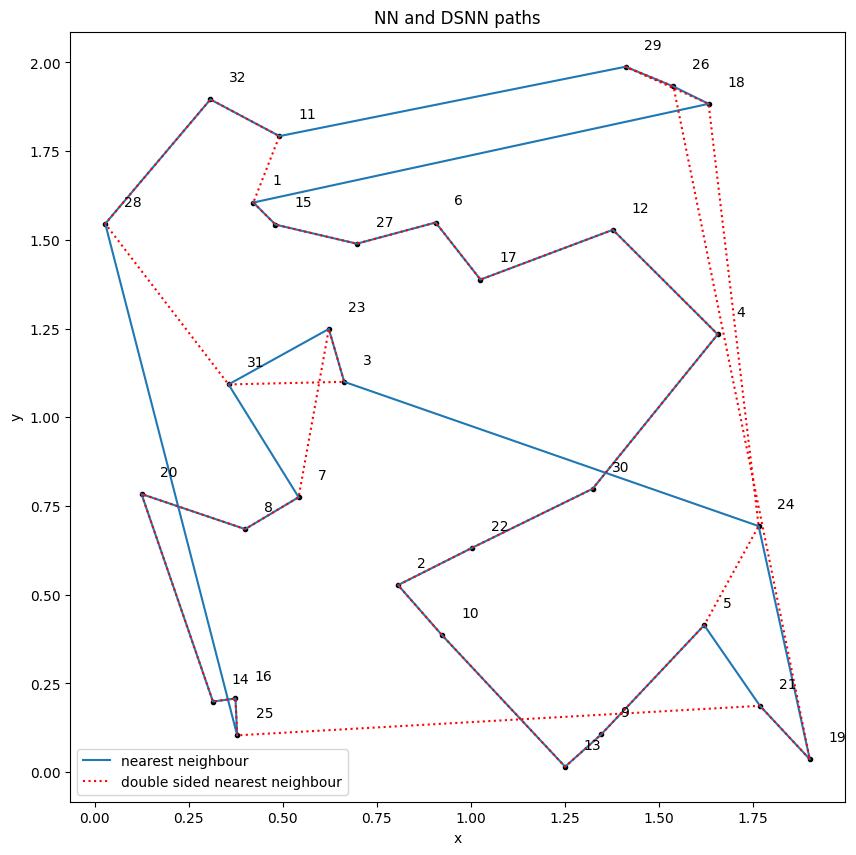

In [5]:
z = []
for i in range(len(xPos)):
    z.append(str(i+1))
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot()

plt.scatter(xPos, yPos, marker = '.', color = 'black')
plt.plot(xPos_NN_order, yPos_NN_order, label = 'nearest neighbour')
plt.plot(xPos_DSNN_order, yPos_DSNN_order, label = 'double sided nearest neighbour', linestyle = 'dotted', color = 'red')
plt.ylabel("y")
plt.xlabel("x")
plt.title("NN and DSNN paths")

for i, txt in enumerate(z):
    ax.text(xPos[i]+0.05, yPos[i]+0.05, txt)


plt.legend()
plt.show()

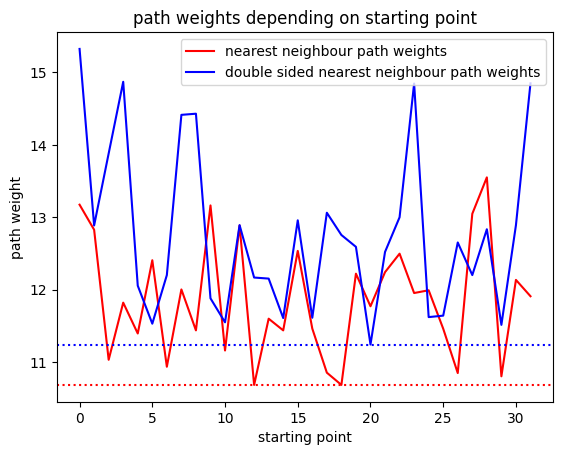

In [6]:
plt.plot(points, weightsNN, label = 'nearest neighbour path weights', color = 'red')
plt.plot(points, weightsDSNN, label = 'double sided nearest neighbour path weights', color = 'blue')
plt.axhline(minWeightNN, color = 'red', linestyle = 'dotted')
plt.axhline(minWeightDSNN, color = 'blue', linestyle = 'dotted')
plt.xlabel('starting point')
plt.ylabel('path weight')
plt.title('path weights depending on starting point')

plt.legend()
plt.show()

In [7]:
weightsMC, pathsMC, tempsMC = base.traveling_MC_constDist_history_adaptiveTemp(points.astype(int), distances, 20000, alpha = 0.999, method=2)

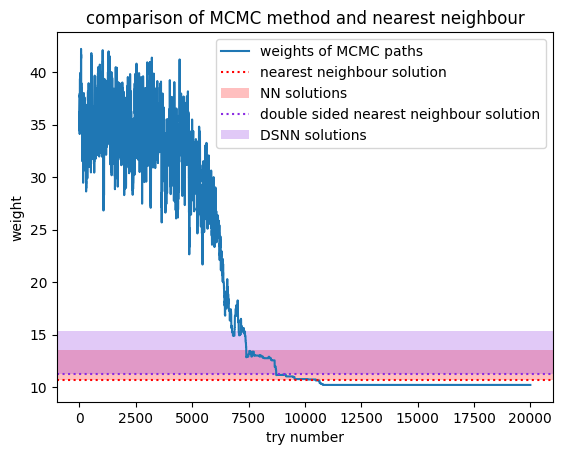

In [8]:
plt.plot(np.linspace(0, 20000, 20001), weightsMC, label = 'weights of MCMC paths')
plt.axhline(minWeightNN, label = 'nearest neighbour solution', linestyle = 'dotted', color = 'red')
plt.axhspan(minWeightNN, np.max(weightsNN), label = 'NN solutions', facecolor='red', alpha=0.25)
plt.axhline(minWeightDSNN, label = 'double sided nearest neighbour solution', linestyle = 'dotted', color = 'blueviolet')
plt.axhspan(minWeightDSNN, np.max(weightsDSNN), label = 'DSNN solutions', facecolor = 'blueviolet', alpha = 0.25)
#plt.axhline(np.min(weightsChistofides), label = 'Christofides solution', linestyle = 'dotted', color = 'aqua')
#plt.axhspan(np.min(weightsChistofides), np.max(weightsChistofides), label = 'Christofidis', facecolor = 'aqua', alpha = 0.1)
#plt.axhline(weightNearestInsertion, label = 'nearest insertion solution', linestyle = 'dotted', color = 'olive')
plt.xlabel('try number')
plt.ylabel('weight')
plt.title('comparison of MCMC method and nearest neighbour')

plt.legend()
plt.show()

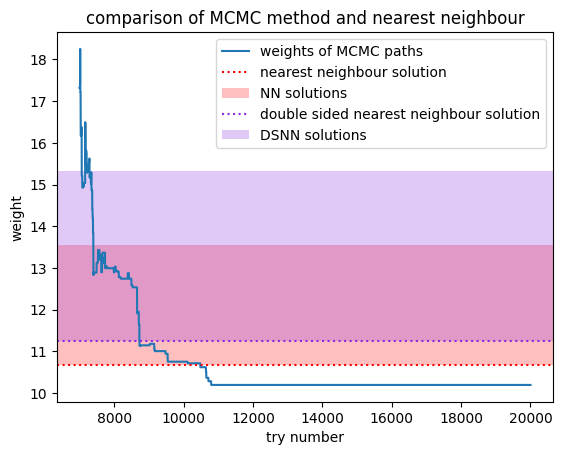

In [9]:
plt.plot(np.linspace(7000, 20000, 13001), weightsMC[7000:], label = 'weights of MCMC paths')
plt.axhline(minWeightNN, label = 'nearest neighbour solution', linestyle = 'dotted', color = 'red')
plt.axhspan(minWeightNN, np.max(weightsNN), label = 'NN solutions', facecolor='red', alpha=0.25)
plt.axhline(minWeightDSNN, label = 'double sided nearest neighbour solution', linestyle = 'dotted', color = 'blueviolet')
plt.axhspan(minWeightDSNN, np.max(weightsDSNN), label = 'DSNN solutions', facecolor = 'blueviolet', alpha = 0.25)
#plt.axhline(np.min(weightsChistofides), label = 'Christofides solution', linestyle = 'dotted', color = 'aqua')
#plt.axhspan(np.min(weightsChistofides), np.max(weightsChistofides), label = 'Christofidis', facecolor = 'aqua', alpha = 0.1)
#plt.axhline(weightNearestInsertion, label = 'nearest insertion solution', linestyle = 'dotted', color = 'olive')
plt.xlabel('try number')
plt.ylabel('weight')
plt.title('comparison of MCMC method and nearest neighbour')

plt.legend()
plt.show()

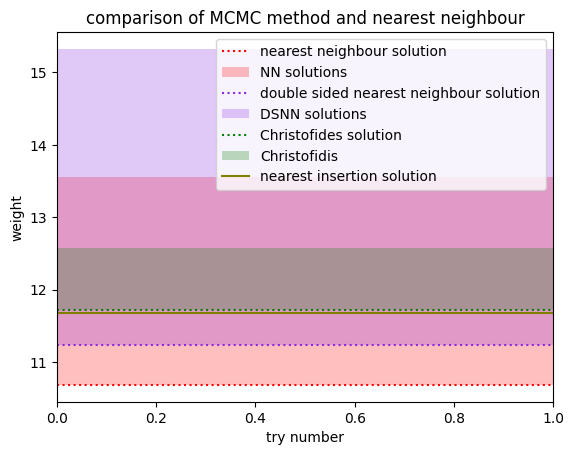

In [13]:
plt.axhline(minWeightNN, label = 'nearest neighbour solution', linestyle = 'dotted', color = 'red')
plt.axhspan(minWeightNN, np.max(weightsNN), label = 'NN solutions', facecolor='red', alpha=0.25)
plt.axhline(minWeightDSNN, label = 'double sided nearest neighbour solution', linestyle = 'dotted', color = 'blueviolet')
plt.axhspan(minWeightDSNN, np.max(weightsDSNN), label = 'DSNN solutions', facecolor = 'blueviolet', alpha = 0.25)
plt.axhline(np.min(weightsChristofides), label = 'Christofides solution', linestyle = 'dotted', color = 'green')
plt.axhspan(np.min(weightsChristofides), np.max(weightsChristofides), label = 'Christofidis', facecolor = 'green', alpha = 0.25)
plt.axhline(weightNearestInsertion, label = 'nearest insertion solution', color = 'olive')
plt.xlabel('try number')
plt.ylabel('weight')
plt.title('comparison of MCMC method and nearest neighbour')

plt.legend()
plt.show()

In [15]:
weightsMC_T1, pathsMC_T1, tempsMC_T1 = base.traveling_MC_constDist_history(points.astype(int), distances, 20000, 1, alpha = 0.99, method=2)
weightsMC_T200, pathsMC_BigT200, tempsMC_BigT200 = base.traveling_MC_constDist_history(points.astype(int), distances, 20000, 200, alpha = 0.99, method=2)
weightsMC_BigT1, pathsMC_BigT1, tempsMC_BigT1 = base.traveling_MC_constDist_history(points.astype(int), distances, 20000, 1, alpha = 0.99, method=2)
weightsMC_BigT200, pathsMC_BigT200, tempsMC_BigT200 = base.traveling_MC_constDist_history(points.astype(int), distances, 20000, 200, alpha = 0.99, method=2)
weightsMC_Big_adaptive, pathsMC_Big_adaptive, tempsMC_Big_adaptive = base.traveling_MC_constDist_history_adaptiveTemp(points.astype(int), distances, 20000, alpha = 0.99, method=2)

/home/user/Physik_Bonn/CompPhys/project/base.py:206: RuntimeWarning: overflow encountered in exp
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):
/home/user/Physik_Bonn/CompPhys/project/base.py:243: RuntimeWarning: overflow encountered in exp
  if np.random.uniform(low=0, high=1) < np.exp((pathWeights[i]-new_cost)/temps[i]):


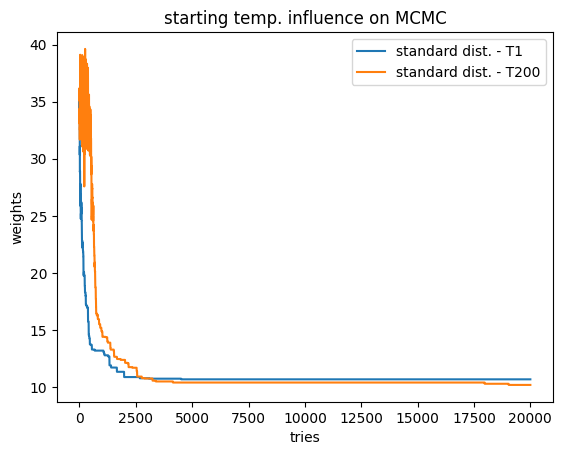

In [16]:
plt.plot(np.linspace(0, 20000, 20001), weightsMC_T1, label = 'standard dist. - T1')
plt.plot(np.linspace(0, 20000, 20001), weightsMC_T200, label = 'standard dist. - T200')
plt.xlabel('tries')
plt.ylabel('weights')
plt.title('starting temp. influence on MCMC')

plt.legend()
plt.show()

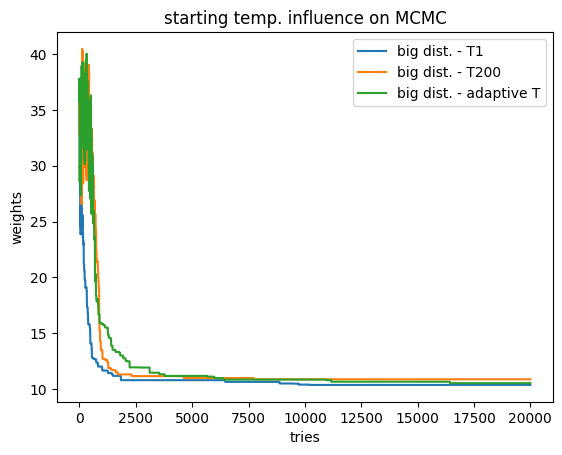

In [18]:
plt.plot(np.linspace(0, 20000, 20001), weightsMC_BigT1, label = 'big dist. - T1')
plt.plot(np.linspace(0, 20000, 20001), weightsMC_BigT200, label = 'big dist. - T200')
plt.plot(np.linspace(0, 20000, 20001), weightsMC_Big_adaptive, label = 'big dist. - adaptive T')
plt.xlabel('tries')
plt.ylabel('weights')
plt.title('starting temp. influence on MCMC')

plt.legend()
plt.show()